In [29]:
!pip install pandas numpy scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import numpy as np


deliveries = pd.read_csv("../datasets/deliveries.csv")
matches = pd.read_csv("../datasets/matches.csv")


In [31]:
!pip install pandas numpy scikit-learn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
deliveries.head()
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [34]:
deliveries.shape
matches.shape
deliveries.columns
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [35]:
deliveries.info()
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [36]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [37]:
deliveries.isna().sum()
matches.isna().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [38]:
deliveries = deliveries.drop_duplicates()
matches = matches.drop_duplicates()

In [39]:
matches['winner'] = matches['winner'].fillna('NO RESULT')

In [40]:
matches['city'] = matches['city'].fillna('UNKNOWN')
matches['venue'] = matches['venue'].fillna('UNKNOWN')

In [41]:
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('NOT OUT')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('NONE')
deliveries['fielder'] = deliveries['fielder'].fillna('NONE')

In [42]:
matches['date'] = pd.to_datetime(matches['date'])
matches['year'] = matches['date'].dt.year

In [43]:
def clean_text(col):
    return (
        col.astype(str)
           .str.strip()
           .str.replace(r'\s+', ' ', regex=True)
           .str.upper()
    )

deliveries['batter'] = clean_text(deliveries['batter'])
deliveries['bowler'] = clean_text(deliveries['bowler'])
deliveries['non_striker'] = clean_text(deliveries['non_striker'])


matches['team1'] = clean_text(matches['team1'])
matches['team2'] = clean_text(matches['team2'])
matches['winner'] = clean_text(matches['winner'])


In [44]:
deliveries['player_dismissed'] = (
    deliveries['player_dismissed']
    .fillna('NOT OUT')
    .astype(str)
    .str.upper()
)

deliveries['dismissal_kind'] = (
    deliveries['dismissal_kind']
    .fillna('NONE')
    .astype(str)
    .str.upper()
)

deliveries['fielder'] = (
    deliveries['fielder']
    .fillna('NONE')
    .astype(str)
    .str.upper()
)


In [45]:
deliveries['is_wicket'] = deliveries['dismissal_kind'].apply(
    lambda x: 0 if x == 'NONE' else 1
)

In [46]:
matches['player_of_match'] = matches['player_of_match'].fillna('NO AWARD')

In [47]:
matches['result_margin'] = matches['result_margin'].fillna(0)

In [48]:
matches['target_runs'] = matches['target_runs'].fillna(0)

In [49]:
matches['target_overs'] = matches['target_overs'].fillna(0)

In [50]:
matches['method'] = matches['method'].fillna('NORMAL')

In [51]:
deliveries.isna().sum()
matches.isna().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
year               0
dtype: int64

In [52]:
text_cols = [
    'city','venue','team1','team2','toss_winner',
    'winner','result','method','player_of_match'
]

for col in text_cols:
    matches[col] = (
        matches[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

In [53]:
deliveries['extras_type'] = deliveries['extras_type'].fillna('NONE')


In [54]:
deliveries.isna().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [55]:
deliveries.to_csv("../datasets/deliveries_cleaned.csv", index=False)
matches.to_csv("../datasets/matches_cleaned.csv", index=False)

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [57]:
pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
     --------------- ------------------------ 30.7/78.5 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/78.5 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/78.5 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/78.5 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 78.5/78.5 kB 437.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
deliveries = pd.read_csv("../datasets/deliveries_cleaned.csv")
matches = pd.read_csv("../datasets/matches_cleaned.csv")
deliveries['legal_ball'] = deliveries['extras_type'].apply(
    lambda x: 0 if x in ['WIDE', 'NO BALL'] else 1
)

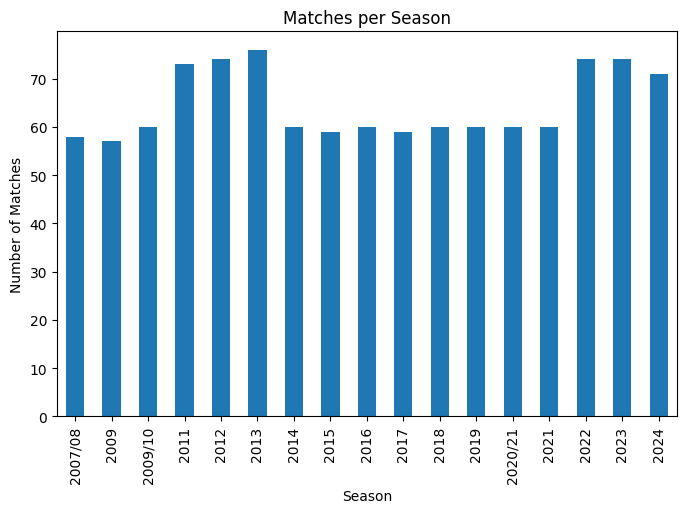

In [59]:
#Matches per Season (Bar Chart – Matplotlib)
plt.figure(figsize=(8,5))
matches['season'].value_counts().sort_index().plot(kind='bar')
plt.title("Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

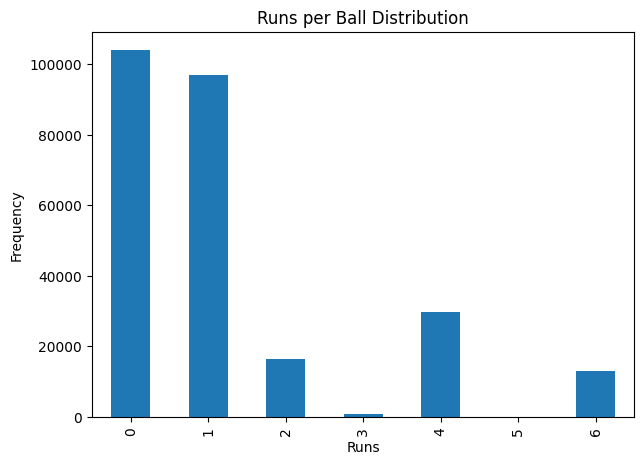

In [60]:
#Runs per ball distribution
plt.figure(figsize=(7,5))
deliveries['batsman_runs'].value_counts().sort_index().plot(kind='bar')
plt.title("Runs per Ball Distribution")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


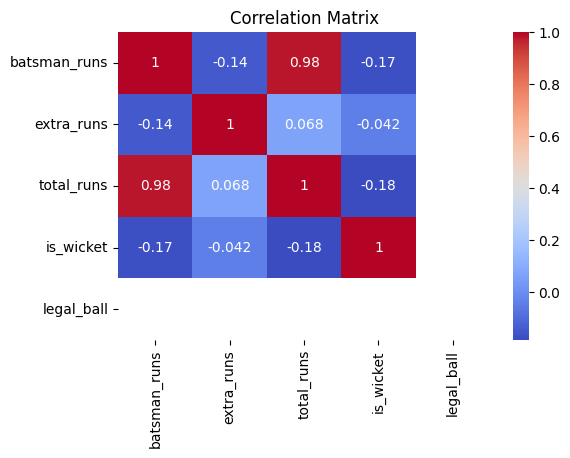

In [61]:

#Correlation heatmap(Seaborn)
numeric_cols = ['batsman_runs','extra_runs','total_runs','is_wicket','legal_ball']
corr = deliveries[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


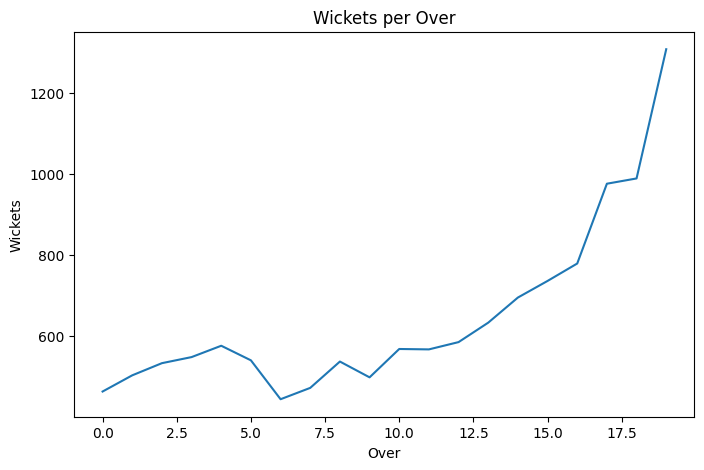

In [62]:
#Wickets by over(Seaborn line plot)
wickets_over = deliveries.groupby('over')['is_wicket'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=wickets_over, x='over', y='is_wicket')
plt.title("Wickets per Over")
plt.xlabel("Over")
plt.ylabel("Wickets")
plt.show()


In [63]:

#toss decision distribution(pie-plotly)
toss_df = matches['toss_decision'].value_counts().reset_index()
toss_df.columns = ['decision','count']

fig = px.pie(
    toss_df,
    names='decision',
    values='count',
    title="Toss Decision Distribution"
)
fig.show()


In [64]:
#top 10 teams by wins
team_wins = matches['winner'].value_counts().head(10).reset_index()
team_wins.columns = ['team','wins']

fig = px.bar(
    team_wins,
    x='team',
    y='wins',
    title="Top 10 Teams by Wins",
    color='wins'
)
fig.show()


In [65]:
#top 10 batsmen by runs
top_batsmen = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_batsmen,
    x='batter',
    y='batsman_runs',
    title="Top 10 Batsmen by Runs",
    color='batsman_runs'
)
fig.show()


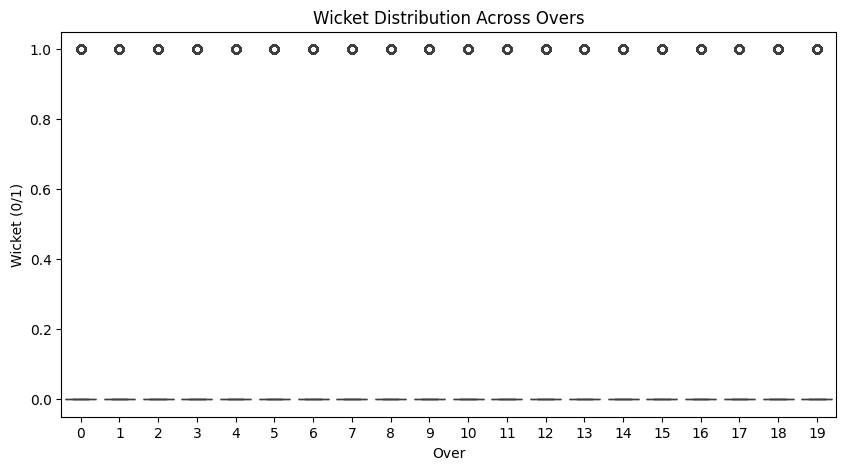

In [66]:
#wickets vs over
plt.figure(figsize=(10,5))
sns.boxplot(data=deliveries, x='over', y='is_wicket')
plt.title("Wicket Distribution Across Overs")
plt.xlabel("Over")
plt.ylabel("Wicket (0/1)")
plt.show()


In [67]:
#match result by toss decision(plotly - grouped bar)
result_toss = (
    matches.groupby(['toss_decision','result'])
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    result_toss,
    x='toss_decision',
    y='count',
    color='result',
    barmode='group',
    title="Match Result by Toss Decision"
)
fig.show()


In [68]:
#teamwise toss wins(plotly-bar)
toss_wins = matches['toss_winner'].value_counts().head(10).reset_index()
toss_wins.columns = ['team','toss_wins']

fig = px.bar(
    toss_wins,
    x='team',
    y='toss_wins',
    title="Top 10 Teams by Toss Wins",
    color='toss_wins'
)
fig.show()


In [69]:
#extras contribution(plotly - pie)
extras_sum = deliveries.groupby('extras_type')['extra_runs'].sum().reset_index()

fig = px.pie(
    extras_sum,
    names='extras_type',
    values='extra_runs',
    title="Contribution of Extras to Total Runs"
)
fig.show()


In [70]:
#over wise run comparison
over_runs = deliveries.groupby('over')['total_runs'].sum().reset_index()

fig = px.line(
    over_runs,
    x='over',
    y='total_runs',
    title="Total Runs Scored per Over"
)
fig.show()


In [71]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'legal_ball'],
      dtype='object')

In [72]:
deliveries.to_csv("../datasets/deliveries_cleaned.csv", index=False)
matches.to_csv("../datasets/matches_cleaned.csv", index=False)
